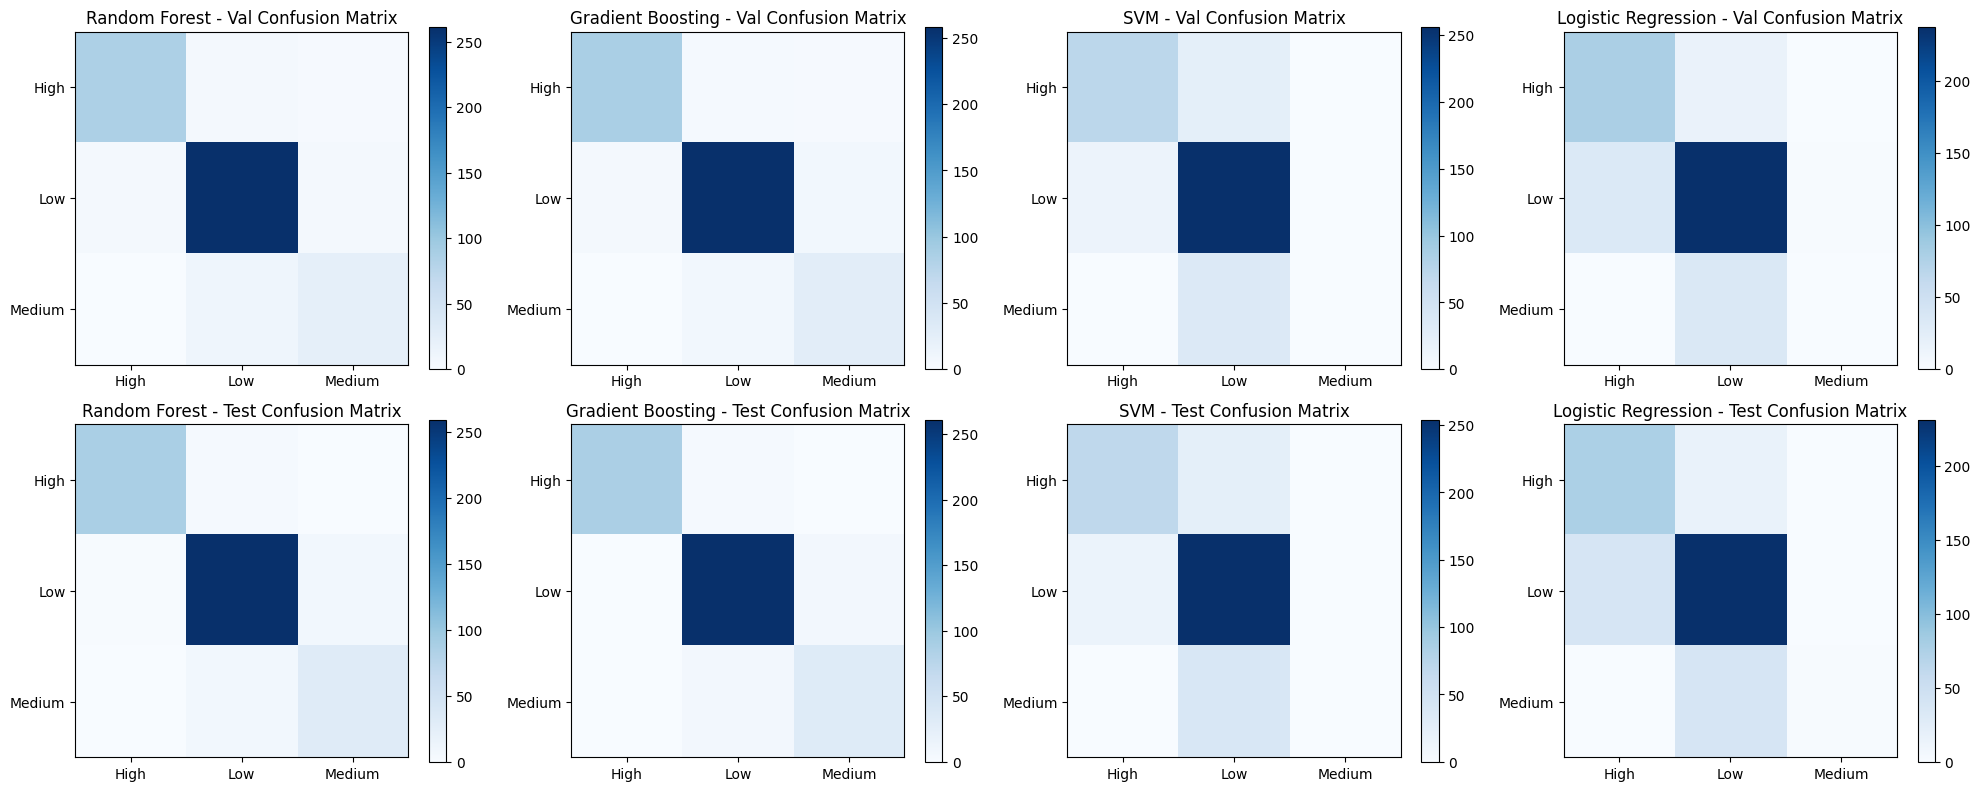


Validation Results:
                  Model  Accuracy  Precision  Recall  F1-Score      RMSE
0        Random Forest    0.9225   0.920654  0.9225  0.921114  0.316228
1    Gradient Boosting    0.9300   0.931788  0.9300  0.930757  0.304138
2                  SVM    0.8175   0.746368  0.8175  0.778346  0.427200
3  Logistic Regression    0.7900   0.725228  0.7900  0.755753  0.458258

Test Results:
                  Model  Accuracy  Precision  Recall  F1-Score      RMSE
0        Random Forest    0.9450   0.945110  0.9450  0.945019  0.234521
1    Gradient Boosting    0.9500   0.950690  0.9500  0.950202  0.239792
2                  SVM    0.8075   0.729482  0.8075  0.764324  0.438748
3  Logistic Regression    0.7700   0.795912  0.7700  0.735405  0.479583


C:\Users\bhara\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bhara\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


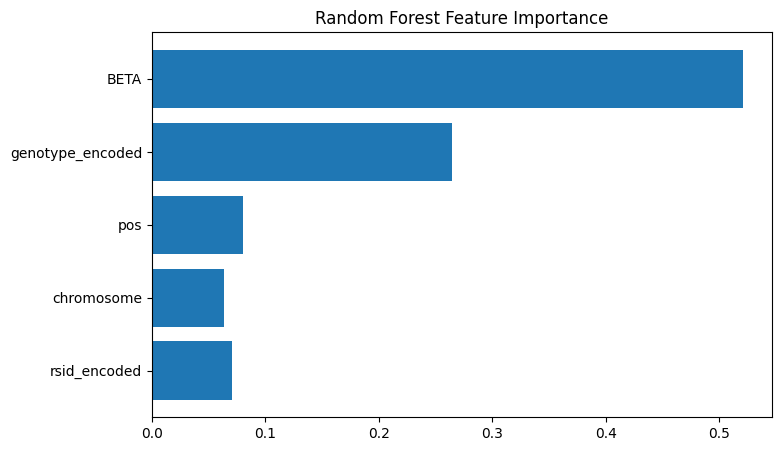


GENETIC RISK PREDICTION SYSTEM

BETA SCORE ANALYSIS
Total SNPs with beta scores: 1876
Average beta score: 0.2550
Median beta score: 0.0253
Standard deviation: 0.5916
Min beta score: 0.0079
Max beta score: 2.6197


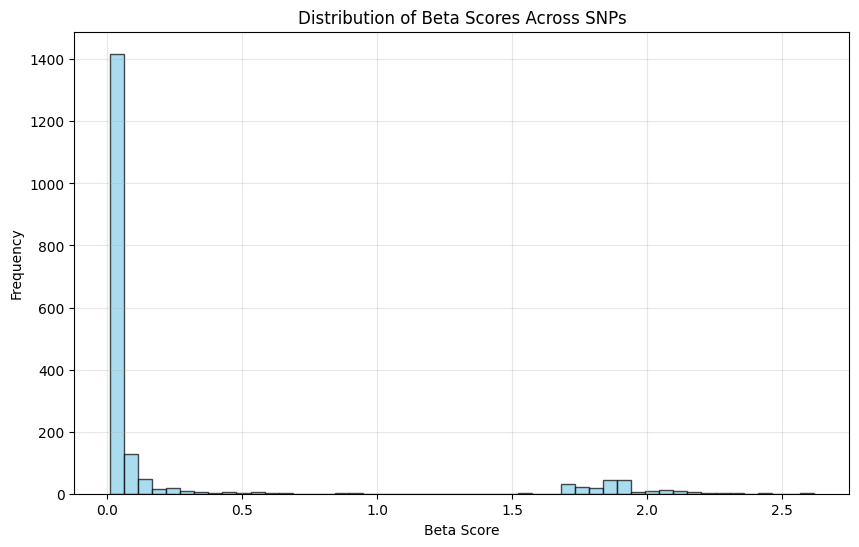


Top 10 SNPs by absolute beta score:
--------------------------------------------------------------------------------
rs10500355: Beta = 2.6197, Disease = Spherical equivalent or myopia (age of diagnosis)
rs9401452: Beta = 2.4207, Disease = Intelligence
rs6495367: Beta = 2.3226, Disease = Spherical equivalent or myopia (age of diagnosis)
rs11145465: Beta = 2.2561, Disease = Spherical equivalent or myopia (age of diagnosis)
rs1649068: Beta = 2.2449, Disease = Spherical equivalent or myopia (age of diagnosis)
rs7692381: Beta = 2.2405, Disease = Spherical equivalent or myopia (age of diagnosis)
rs9320747: Beta = 2.2176, Disease = Intelligence
rs56075542: Beta = 2.1966, Disease = Spherical equivalent or myopia (age of diagnosis)
rs7895108: Beta = 2.1822, Disease = Spherical equivalent or myopia (age of diagnosis)
rs1556867: Beta = 2.1754, Disease = Spherical equivalent or myopia (age of diagnosis)

DISEASE ASSOCIATION ANALYSIS

Top 15 Diseases by Number of Associated SNPs:
----------------

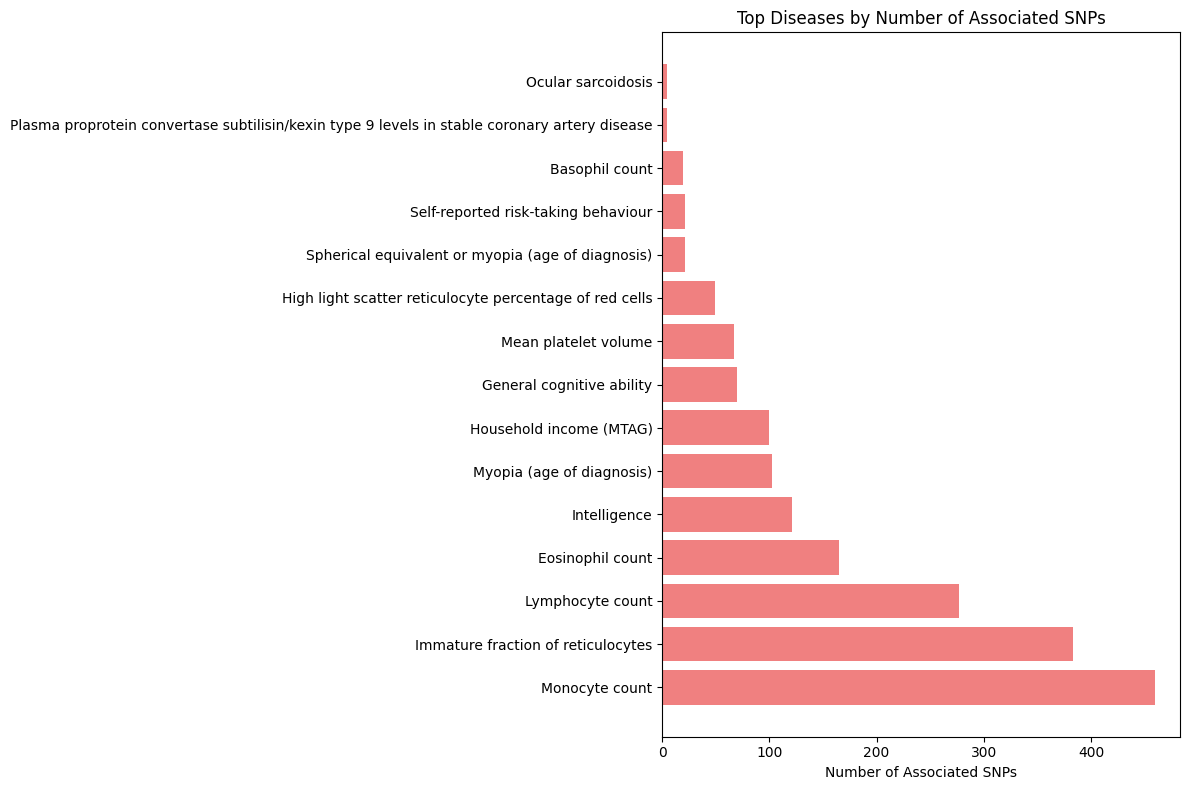


REAL SNP DATA ANALYSIS
Found 632 real SNPs with beta scores in patient data

Top 10 Real SNPs by Beta Score:
--------------------------------------------------------------------------------
rs10500355: Beta = 2.6197, Disease = Spherical equivalent or myopia (age of diagnosis)
rs9401452: Beta = 2.4207, Disease = Intelligence
rs6495367: Beta = 2.3226, Disease = Spherical equivalent or myopia (age of diagnosis)
rs11145465: Beta = 2.2561, Disease = Spherical equivalent or myopia (age of diagnosis)
rs1649068: Beta = 2.2449, Disease = Spherical equivalent or myopia (age of diagnosis)
rs7692381: Beta = 2.2405, Disease = Spherical equivalent or myopia (age of diagnosis)
rs9320747: Beta = 2.2176, Disease = Intelligence
rs56075542: Beta = 2.1966, Disease = Spherical equivalent or myopia (age of diagnosis)
rs7895108: Beta = 2.1822, Disease = Spherical equivalent or myopia (age of diagnosis)
rs1556867: Beta = 2.1754, Disease = Spherical equivalent or myopia (age of diagnosis)

PATIENT GENETIC PRO

C:\Users\bhara\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\bhara\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
C:\Users\bhara\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhara\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bhara\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid f

In [3]:
# -----------------------------------------------
# IMPORTS
# -----------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, mean_squared_error
)

# -----------------------------------------------
# LOAD DATA
# -----------------------------------------------

gwas_df = pd.read_csv('GWAS_clean_disease.csv')
patients_df = pd.read_csv('patients.csv')

# -----------------------------------------------
# CLEANING & NORMALIZATION
# -----------------------------------------------

gwas_df['SNP'] = gwas_df['SNP'].astype(str).fillna('')
gwas_df = gwas_df.dropna(subset=['RISK_ALLELE'])


def extract_risk_allele(risk_allele_str):
    """Extract only allele part from strings like 'rs123-A', 'rs123-G'"""
    risk_allele_str = str(risk_allele_str)
    parts = risk_allele_str.split('-')
    if len(parts) > 1:
        return parts[-1]
    return ''
    

gwas_df['RISK_ALLELE_CLEAN'] = gwas_df['RISK_ALLELE'].apply(extract_risk_allele)

# -----------------------------------------------
# BUILD SNP → BETA MAP & SNP → DISEASE MAP
# -----------------------------------------------

snp_beta_map = {}
snp_disease_map = {}

for _, row in gwas_df.iterrows():
    snp_value = str(row['SNP']).strip()
    risk_allele_value = str(row['RISK_ALLELE']).strip()
    
    # Get disease name - try different possible column names
    disease_columns = ['DISEASE/TRAIT', 'DISEASE', 'TRAIT', 'PHENOTYPE']
    disease = 'Unknown'
    for col in disease_columns:
        if col in row and pd.notna(row[col]):
            disease = str(row[col])
            break
    
    # Extract SNP ID from SNP column
    if snp_value.startswith('rs'):
        snp_id = snp_value
        snp_beta_map[snp_id] = row['BETA']
        snp_disease_map[snp_id] = disease
    
    # Extract SNP ID from RISK_ALLELE column (format: rs123-A)
    if risk_allele_value.startswith('rs'):
        parts = risk_allele_value.split('-')
        if len(parts) > 0 and parts[0].startswith('rs'):
            snp_id = parts[0]
            snp_beta_map[snp_id] = row['BETA']
            snp_disease_map[snp_id] = disease

# -----------------------------------------------
# MERGE BETA INTO PATIENT DATA
# -----------------------------------------------

patients_df['BETA'] = patients_df['rsid'].map(snp_beta_map).fillna(0)
patients_df['ASSOCIATED_DISEASE'] = patients_df['rsid'].map(snp_disease_map).fillna('Unknown')

# -----------------------------------------------
# CHROMOSOME CLEANING (FIX VALUEERROR)
# -----------------------------------------------

def convert_chromosome(val):
    val = str(val).strip()
    if val == 'X':
        return 23
    elif val == 'Y':
        return 24
    elif val.upper() in ['MT', 'M']:
        return 25
    elif val.isdigit():
        return int(val)
    return np.nan

patients_df['chromosome'] = patients_df['chromosome'].apply(convert_chromosome)
patients_df = patients_df.dropna(subset=['chromosome', 'pos', 'BETA'])
patients_df['chromosome'] = patients_df['chromosome'].astype(int)
patients_df['pos'] = patients_df['pos'].astype(int)

# -----------------------------------------------
# GENOTYPE CLEANING
# -----------------------------------------------

patients_df['genotype'] = patients_df['genotype'].fillna('NN')

# -----------------------------------------------
# PRS CALCULATION
# -----------------------------------------------

def calculate_genotype_score(genotype, risk_allele, beta):
    if pd.isna(risk_allele) or pd.isna(beta): 
        return 0
    
    genotype = str(genotype)
    risk_allele = str(risk_allele)

    if len(risk_allele) == 0:
        return 0

    risk_base = risk_allele[0]
    risk_count = genotype.count(risk_base)

    return risk_count * beta


def get_risk_allele(rsid):
    df = gwas_df[gwas_df['RISK_ALLELE'].str.contains(rsid, na=False)]
    if len(df) == 0:
        return ''
    return df['RISK_ALLELE_CLEAN'].iloc[0]


patients_df['CALCULATED_PRS'] = patients_df.apply(
    lambda row: calculate_genotype_score(
        row['genotype'],
        get_risk_allele(row['rsid']),
        row['BETA']
    ), 
    axis=1
)

# -----------------------------------------------
# PRS GROUP LABELING
# -----------------------------------------------

patients_df['PRS_GROUP'] = pd.cut(
    patients_df['CALCULATED_PRS'],
    bins=[-1, 0.1, 1, 100],
    labels=['Low', 'Medium', 'High']
)

# -----------------------------------------------
# ENCODING
# -----------------------------------------------

le_rsid = LabelEncoder()
le_genotype = LabelEncoder()
le_prs_group = LabelEncoder()

patients_df['rsid_encoded'] = le_rsid.fit_transform(patients_df['rsid'])
patients_df['genotype_encoded'] = le_genotype.fit_transform(patients_df['genotype'])
patients_df['prs_group_encoded'] = le_prs_group.fit_transform(patients_df['PRS_GROUP'])

# -----------------------------------------------
# SPLIT DATA
# -----------------------------------------------

X = patients_df[['rsid_encoded', 'chromosome', 'pos', 'genotype_encoded', 'BETA']]
y = patients_df['prs_group_encoded']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# SCALER FOR SVM & LOGISTIC
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# -----------------------------------------------
# TRAIN MODELS
# -----------------------------------------------

rf_model = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)
svm_model = SVC(probability=True, random_state=42).fit(X_train_scaled, y_train)
lr_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scaled, y_train)

# -----------------------------------------------
# EVALUATION
# -----------------------------------------------

models_val = {
    'Random Forest': rf_model.predict(X_val),
    'Gradient Boosting': gb_model.predict(X_val),
    'SVM': svm_model.predict(X_val_scaled),
    'Logistic Regression': lr_model.predict(X_val_scaled)
}

models_test = {
    'Random Forest': rf_model.predict(X_test),
    'Gradient Boosting': gb_model.predict(X_test),
    'SVM': svm_model.predict(X_test_scaled),
    'Logistic Regression': lr_model.predict(X_test_scaled)
}

results_val = []
results_test = []

# -----------------------------------------------
# CONFUSION MATRIX PLOTS
# -----------------------------------------------

plt.figure(figsize=(20, 8))
for i, (name, pred) in enumerate(models_val.items()):
    cm = confusion_matrix(y_val, pred)
    plt.subplot(2, 4, i+1)
    plt.imshow(cm, cmap='Blues')
    plt.title(f'{name} - Val Confusion Matrix')
    plt.colorbar()
    plt.xticks(range(len(le_prs_group.classes_)), le_prs_group.classes_)
    plt.yticks(range(len(le_prs_group.classes_)), le_prs_group.classes_)

for i, (name, pred) in enumerate(models_test.items()):
    cm = confusion_matrix(y_test, pred)
    plt.subplot(2, 4, i+5)
    plt.imshow(cm, cmap='Blues')
    plt.title(f'{name} - Test Confusion Matrix')
    plt.colorbar()
    plt.xticks(range(len(le_prs_group.classes_)), le_prs_group.classes_)
    plt.yticks(range(len(le_prs_group.classes_)), le_prs_group.classes_)

plt.tight_layout()
plt.show()

# -----------------------------------------------
# METRIC TABLES
# -----------------------------------------------

def evaluate(model_results, X_true):
    rows = []
    for name, pred in model_results.items():
        rows.append({
            'Model': name,
            'Accuracy': accuracy_score(X_true, pred),
            'Precision': precision_score(X_true, pred, average='weighted'),
            'Recall': recall_score(X_true, pred, average='weighted'),
            'F1-Score': f1_score(X_true, pred, average='weighted'),
            'RMSE': np.sqrt(mean_squared_error(X_true, pred)),
        })
    return pd.DataFrame(rows)

results_val_df = evaluate(models_val, y_val)
results_test_df = evaluate(models_test, y_test)

print("\nValidation Results:\n", results_val_df)
print("\nTest Results:\n", results_test_df)

# -----------------------------------------------
# FEATURE IMPORTANCE
# -----------------------------------------------

plt.figure(figsize=(8, 5))
plt.barh(X.columns, rf_model.feature_importances_)
plt.title("Random Forest Feature Importance")
plt.show()

# -----------------------------------------------
# BETA SCORE ANALYSIS FUNCTION
# -----------------------------------------------

def analyze_beta_scores():
    """Analyze and display beta score statistics"""
    print("\n" + "="*60)
    print("BETA SCORE ANALYSIS")
    print("="*60)
    
    # Basic statistics
    beta_scores = list(snp_beta_map.values())
    print(f"Total SNPs with beta scores: {len(beta_scores)}")
    print(f"Average beta score: {np.mean(beta_scores):.4f}")
    print(f"Median beta score: {np.median(beta_scores):.4f}")
    print(f"Standard deviation: {np.std(beta_scores):.4f}")
    print(f"Min beta score: {np.min(beta_scores):.4f}")
    print(f"Max beta score: {np.max(beta_scores):.4f}")
    
    # Beta score distribution
    plt.figure(figsize=(10, 6))
    plt.hist(beta_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Distribution of Beta Scores Across SNPs')
    plt.xlabel('Beta Score')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Top SNPs by absolute beta score
    top_snps = sorted(snp_beta_map.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
    print(f"\nTop 10 SNPs by absolute beta score:")
    print("-" * 80)
    for snp, beta in top_snps:
        disease = snp_disease_map.get(snp, 'Unknown')
        print(f"{snp}: Beta = {beta:.4f}, Disease = {disease}")

# -----------------------------------------------
# DISEASE ASSOCIATION ANALYSIS
# -----------------------------------------------

def analyze_disease_associations():
    """Analyze diseases and their associated SNPs"""
    print("\n" + "="*60)
    print("DISEASE ASSOCIATION ANALYSIS")
    print("="*60)
    
    # Count SNPs per disease
    disease_counts = {}
    for disease in snp_disease_map.values():
        if disease != 'Unknown':
            disease_counts[disease] = disease_counts.get(disease, 0) + 1
    
    if not disease_counts:
        print("No disease information found in the data.")
        # Let's check what diseases are actually in the GWAS data
        print("\nChecking GWAS data for disease columns...")
        disease_cols = [col for col in gwas_df.columns if 'disease' in col.lower() or 'trait' in col.lower()]
        print(f"Potential disease columns: {disease_cols}")
        
        if disease_cols:
            print(f"\nSample diseases from GWAS data:")
            for col in disease_cols:
                unique_diseases = gwas_df[col].dropna().unique()[:5]
                print(f"{col}: {list(unique_diseases)}")
        return
    
    # Top diseases by SNP count
    top_diseases = sorted(disease_counts.items(), key=lambda x: x[1], reverse=True)[:15]
    
    print(f"\nTop 15 Diseases by Number of Associated SNPs:")
    print("-" * 80)
    for disease, count in top_diseases:
        print(f"{disease}: {count} SNPs")
    
    # Plot disease distribution
    plt.figure(figsize=(12, 8))
    diseases, counts = zip(*top_diseases)
    plt.barh(diseases, counts, color='lightcoral')
    plt.xlabel('Number of Associated SNPs')
    plt.title('Top Diseases by Number of Associated SNPs')
    plt.tight_layout()
    plt.show()

# -----------------------------------------------
# SNP DETAILED INFORMATION FUNCTION
# -----------------------------------------------

def get_snp_detailed_info(rsid):
    """Get detailed information for a specific SNP"""
    print(f"\n" + "="*60)
    print(f"DETAILED ANALYSIS FOR SNP: {rsid}")
    print("="*60)
    
    beta_score = snp_beta_map.get(rsid, "Not found")
    associated_disease = snp_disease_map.get(rsid, "Not found")
    
    print(f"SNP ID: {rsid}")
    print(f"Beta Score: {beta_score}")
    print(f"Associated Disease/Trait: {associated_disease}")
    
    # Interpret beta score
    if beta_score != "Not found":
        if abs(beta_score) < 0.1:
            strength = "Weak"
        elif abs(beta_score) < 0.5:
            strength = "Moderate"
        else:
            strength = "Strong"
        
        direction = "risk-increasing" if beta_score > 0 else "risk-decreasing"
        print(f"Effect Strength: {strength}")
        print(f"Effect Direction: {direction}")
    
    # Find similar SNPs
    if beta_score != "Not found":
        similar_snps = []
        for snp, beta in snp_beta_map.items():
            if snp != rsid and abs(beta - beta_score) < 0.1:
                similar_snps.append((snp, beta, snp_disease_map.get(snp, 'Unknown')))
        
        if similar_snps:
            print(f"\nSimilar SNPs (similar beta scores):")
            print("-" * 80)
            for snp, beta, disease in similar_snps[:5]:  # Show top 5
                print(f"{snp}: Beta = {beta:.4f}, Disease = {disease}")

# -----------------------------------------------
# NEW SNP PREDICTION FUNCTION WITH BETA & DISEASE INFO
# -----------------------------------------------

def predict_new_snp(rsid, chromosome, pos, genotype):
    # Get beta score and associated disease
    beta_score = snp_beta_map.get(rsid, 0)
    associated_disease = snp_disease_map.get(rsid, 'Unknown')
    
    print(f"\n=== SNP ANALYSIS FOR {rsid} ===")
    print(f"Beta Score: {beta_score}")
    print(f"Associated Disease/Trait: {associated_disease}")
    print("=" * 40)
    
    try: 
        rsid_encoded = le_rsid.transform([rsid])[0]
    except: 
        rsid_encoded = 0

    try: 
        genotype_encoded = le_genotype.transform([genotype])[0]
    except: 
        genotype_encoded = 0

    chrom = convert_chromosome(chromosome)

    sample = np.array([[rsid_encoded, chrom, pos, genotype_encoded, beta_score]])

    pred = {
        'Random Forest': rf_model.predict(sample)[0],
        'Gradient Boosting': gb_model.predict(sample)[0],
        'SVM': svm_model.predict(scaler.transform(sample))[0],
        'Logistic Regression': lr_model.predict(scaler.transform(sample))[0]
    }

    return {k: le_prs_group.inverse_transform([v])[0] for k, v in pred.items()}

# -----------------------------------------------
# PATIENT-SPECIFIC ANALYSIS
# -----------------------------------------------

def analyze_patient_genetic_profile(patient_id=None):
    """Analyze genetic profile for a specific patient or all patients"""
    print(f"\n" + "="*80)
    print("PATIENT GENETIC PROFILE ANALYSIS")
    print("="*80)
    
    if patient_id:
        patient_data = patients_df[patients_df['patient_id'] == patient_id] if 'patient_id' in patients_df.columns else patients_df.iloc[:1]
    else:
        patient_data = patients_df
    
    print(f"Analyzing {len(patient_data)} patient records...")
    
    # Calculate risk summary
    high_risk_snps = patient_data[patient_data['BETA'] > 0.5]
    moderate_risk_snps = patient_data[(patient_data['BETA'] > 0.1) & (patient_data['BETA'] <= 0.5)]
    low_risk_snps = patient_data[patient_data['BETA'] <= 0.1]
    
    print(f"\nRisk Profile Summary:")
    print(f"High-risk SNPs (beta > 0.5): {len(high_risk_snps)}")
    print(f"Moderate-risk SNPs (0.1 < beta ≤ 0.5): {len(moderate_risk_snps)}")
    print(f"Low-risk SNPs (beta ≤ 0.1): {len(low_risk_snps)}")
    
    # Top risk SNPs for this patient
    if len(patient_data) > 0:
        top_risk = patient_data.nlargest(5, 'BETA')[['rsid', 'BETA', 'ASSOCIATED_DISEASE']]
        print(f"\nTop 5 Highest Risk SNPs:")
        print("-" * 80)
        for _, row in top_risk.iterrows():
            print(f"{row['rsid']}: Beta = {row['BETA']:.4f}, Disease = {row['ASSOCIATED_DISEASE']}")

# -----------------------------------------------
# REAL DATA ANALYSIS
# -----------------------------------------------

def analyze_real_data_snps():
    """Analyze actual SNPs from the patient data"""
    print(f"\n" + "="*80)
    print("REAL SNP DATA ANALYSIS")
    print("="*80)
    
    # Get actual SNPs from patient data that have beta scores
    real_snps_with_beta = patients_df[patients_df['BETA'] != 0]['rsid'].unique()
    
    print(f"Found {len(real_snps_with_beta)} real SNPs with beta scores in patient data")
    
    if len(real_snps_with_beta) > 0:
        # Show top real SNPs by beta score
        real_snp_betas = []
        for snp in real_snps_with_beta:
            beta = snp_beta_map.get(snp, 0)
            disease = snp_disease_map.get(snp, 'Unknown')
            real_snp_betas.append((snp, beta, disease))
        
        # Sort by absolute beta score
        real_snp_betas.sort(key=lambda x: abs(x[1]), reverse=True)
        
        print(f"\nTop 10 Real SNPs by Beta Score:")
        print("-" * 80)
        for snp, beta, disease in real_snp_betas[:10]:
            print(f"{snp}: Beta = {beta:.4f}, Disease = {disease}")

# -----------------------------------------------
# MAIN EXECUTION
# -----------------------------------------------

print("\n" + "="*80)
print("GENETIC RISK PREDICTION SYSTEM")
print("="*80)

# Run comprehensive analyses
analyze_beta_scores()
analyze_disease_associations()
analyze_real_data_snps()

# Run patient analysis
analyze_patient_genetic_profile()

# Demo prediction with real SNPs from the data
print("\n" + "="*80)
print("DEMO PREDICTIONS WITH REAL SNPS")
print("="*80)

# Use actual SNPs from the patient data for demo
real_snps_for_demo = patients_df['rsid'].unique()[:3]  # Use first 3 unique SNPs

for rsid in real_snps_for_demo:
    # Get the first occurrence of this SNP to get its details
    snp_data = patients_df[patients_df['rsid'] == rsid].iloc[0]
    
    pred = predict_new_snp(
        rsid=rsid,
        chromosome=snp_data['chromosome'],
        pos=snp_data['pos'],
        genotype=snp_data['genotype']
    )
    
    print(f"\nModel Predictions for {rsid}:")
    print("-" * 40)
    for model, group in pred.items():
        print(f"{model}: {group}")
    
    # Get detailed information
    get_snp_detailed_info(rsid)
    print("\n" + "-" * 80)

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

In [6]:
import pickle

save_bundle = {
    "rf_model": rf_model,
    "gb_model": gb_model,
    "svm_model": svm_model,
    "lr_model": lr_model,
    "le_rsid": le_rsid,
    "le_genotype": le_genotype,
    "le_prs_group": le_prs_group,
    "scaler": scaler,
    "snp_beta_map": snp_beta_map,
    "snp_disease_map": snp_disease_map
}

with open("genetic_prediction_bundle.pkl", "wb") as f:
    pickle.dump(save_bundle, f)

print("✔ All important files saved successfully!")


✔ All important files saved successfully!


In [7]:
print(gwas_df.columns)
print(patients_df.columns)


Index(['DISEASE', 'SNP', 'RISK_ALLELE', 'BETA', 'CHR', 'RISK_ALLELE_CLEAN'], dtype='object')
Index(['id', 'rsid', 'chromosome', 'pos', 'genotype', 'PRS', 'BETA',
       'ASSOCIATED_DISEASE', 'CALCULATED_PRS', 'PRS_GROUP', 'rsid_encoded',
       'genotype_encoded', 'prs_group_encoded'],
      dtype='object')
